#katleen

#objetivo 
realizar un análisis estadísticos descriptivo del conjunto de datos de accidentes de tránsito utilizando medidas de tendencia central, gráficos de distrubucion, coeficiente de asimetría de Pearson, curtosis y puntacion Z.    

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from scipy import stats 

In [2]:
# Leer el archivo de Excel 
df = pd.read_excel("../Datos/Accidentes de Transito - Dataset.xlsx")

# Mostrar las primeras 5 filas 
df.head()

,Mes,Año,Accidentes,Temperatura Prom. del Mes (°C),Acum. Lluvia Diaria,Días Hábiles del mes,Inicio de Clases,Precio Gasolina (95 Octanos),Accidentes del mes anterior,IMAE
0,Enero,2017,2683,27.15,0.00,22,0,0.77,3237,309.60
1,Febrero,2017,2606,27.35,18.50,20,0,0.75,2683,312.23
2,Marzo,2017,3033,28.55,6.35,23,1,0.73,2606,315.04
3,Abril,2017,2738,28.70,60.50,20,0,0.75,3033,317.64
4,Mayo,2017,2972,27.85,228.95,23,0,0.75,2738,319.50


In [3]:

import os 

os.getcwd()

'c:\\Users\\katle\\OneDrive\\DLA segundo semestres\\Documentos\\PROYECTO SEMESTRAL ST\\accidentes-transito-panama\\Notebooks'

In [4]:
os.listdir()

['Notebook_Diosa.ipynb',
 'Notebook_Evan.ipynb',
 'Notebook_Katleen.ipynb',
 'Resumen.ipynb']

In [5]:
import os 

os.listdir("../Datos")

['Accidentes de Transito - Dataset.csv',
 'Accidentes de Transito - Dataset.xlsx']

In [6]:
# Ver el tamaño del conjunto de datos 
df.shape

(93, 10)

In [7]:
# Ver los nombres de las columnas
df.columns


Index(['Mes', 'Año', 'Accidentes', 'Temperatura Prom. del Mes (°C)',
       'Acum. Lluvia Diaria', 'Días Hábiles del mes', 'Inicio de Clases',
       'Precio Gasolina (95 Octanos)', 'Accidentes del mes anterior', 'IMAE'],
      dtype='str')

In [8]:
# Información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Mes                             93 non-null     str    
 1   Año                             93 non-null     int64  
 2   Accidentes                      93 non-null     int64  
 3   Temperatura Prom. del Mes (°C)  93 non-null     float64
 4   Acum. Lluvia Diaria             93 non-null     float64
 5   Días Hábiles del mes            93 non-null     int64  
 6   Inicio de Clases                93 non-null     int64  
 7   Precio Gasolina (95 Octanos)    93 non-null     float64
 8   Accidentes del mes anterior     93 non-null     int64  
 9   IMAE                            93 non-null     float64
dtypes: float64(4), int64(5), str(1)
memory usage: 7.4 KB


In [9]:
# Seleccionar la variable que vamos a analizar 
variable = df["Accidentes"]

# Mostrar los primeros valores 
variable.head()

0    2683
1    2606
2    3033
3    2738
4    2972
Name: Accidentes, dtype: int64

In [10]:
# Calcular las medidas de tendencia central 

media = variable.mean()
mediana = variable.median()
moda = variable.mode()[0]

print(f"Mediana: {media:.2f}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")

Mediana: 2440.47
Mediana: 2435.0
Moda: 1967


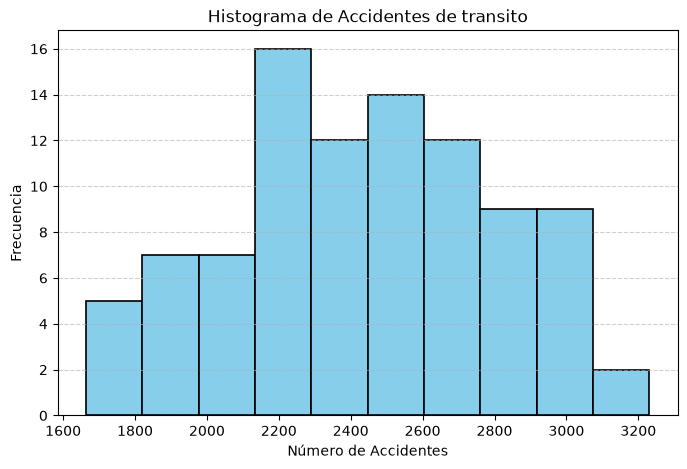

In [11]:
# Histograma de la variable Accidentes
plt.figure(figsize=(8,5))
plt.hist(variable, bins=10, edgecolor= 'black', linewidth=1.2, color="skyblue")
plt.title("Histograma de Accidentes de transito")
plt.xlabel("Número de Accidentes")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#El histograma muestra que la mayor concentración de meses presenta entre aproximadamente 2100 y 2700 accidentes. Se observan menos meses con valores muy bajos (cerca de 1700) o muy altos (por encima de 3000), lo que indica que la mayoría de los registros se agrupan en el centro de la distribución.#


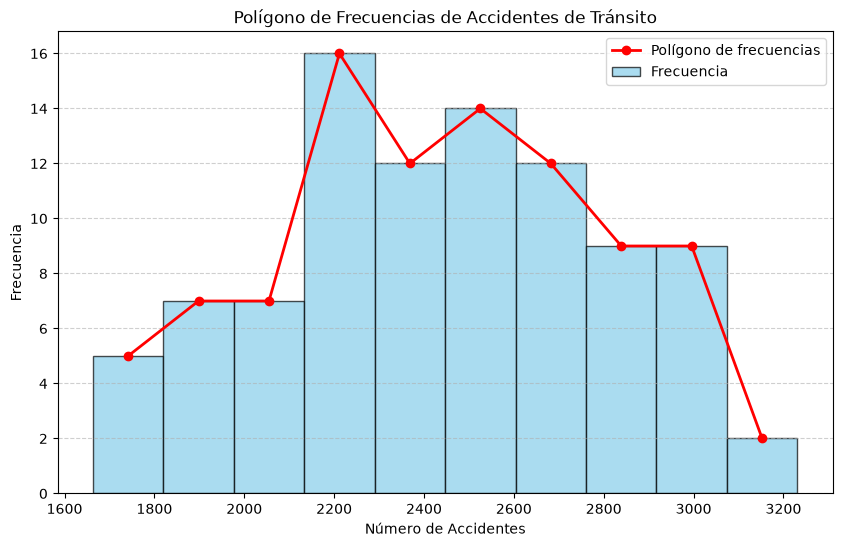

In [12]:
# Calcular frecuencia e intervalos
frecuencias, intervalos = np.histogram(variable, bins=10)
# Calcular los puntos medios 
puntos_medios = (intervalos[:-1]+ intervalos[1:]) /2
# Calcular el ancho de cada barra 
ancho_intervalo = intervalos[1] - intervalos[0]

# Poligono de frecuencias 
plt.figure(figsize=(10,6))
# Barras
plt.bar(
    puntos_medios,
    frecuencias,
    width=ancho_intervalo,
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
    label="Frecuencia"
)

# Polígono
plt.plot(
    puntos_medios,
    frecuencias,
    color="red",
    marker="o",
    linewidth=2,
    label="Polígono de frecuencias"
)

# Títulos
plt.title("Polígono de Frecuencias de Accidentes de Tránsito")
plt.xlabel("Número de Accidentes")
plt.ylabel("Frecuencia")

# Cuadrícula y leyenda
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend()

plt.show()


#El polígono de frecuencias muestra que la mayor cantidad de observaciones se concentra en los intervalos centrales. La frecuencia disminuye hacia los extremos, indicando que los valores muy bajos y muy altos de accidentes son menos frecuentes.


In [13]:
# Calcular la desviacion estándar
desviacion = variable.std()

print("Desviación estándar:", desviacion)

Desviación estándar: 364.7687352937191


#La desviación estándar fue de 364.77 accidentes, lo que indica que la cantidad de accidentes mensuales presenta una variación promedio de aproximadamente 365 accidentes respecto a la media (2440.47). Esto refleja una dispersión moderada en los datos analizados.

In [14]:
# Media y Mediana 
media = variable.mean()
mediana = variable.median()

print("Media: ", media)
print("Mediana: ", mediana)



Media:  2440.47311827957
Mediana:  2435.0


#La media (2440.47) es ligeramente mayor que la mediana (2435), lo que indica una leve asimetría positiva. Sin embargo, la diferencia es pequeña, por lo que la distribución de los accidentes es prácticamente simétrica.

In [15]:
# Calcular la moda 
moda = variable.mode()

print("Moda: ")
print(moda)

Moda: 
0    1967
1    2269
2    2457
Name: Accidentes, dtype: int64


#El conjunto de datos es multimodal, ya que los valores 1967, 2269 y 2457 son los que más se repiten.

In [16]:
# Coeficiente de Asimetría de Pearson 
asimetria = (3 * (media - mediana)) / desviacion 

print("Coeficiente de Asimetría de Pearson: ", asimetria)

Coeficiente de Asimetría de Pearson:  0.045013054162902855


#El coeficiente de asimetría de Pearson fue 0.045, un valor muy cercano a cero. Esto indica que la distribución de la cantidad de accidentes es aproximadamente simétrica, con una ligera inclinación hacia la derecha, pero sin una asimetría significativa.
#

In [17]:
# Curtosis 
from scipy.stats import kurtosis

curt = kurtosis(variable)

print("Curtosis: ", curt)

Curtosis:  -0.6842419807905009


#La curtosis obtenida fue -0.684, lo que indica que la distribución de los accidentes es platicúrtica. Esto significa que la distribución es ligeramente más aplanada que una distribución normal y presenta una menor concentración de datos alrededor de la media.

In [18]:
# Puntuación Z
z= (variable - media) / desviacion 

# Agregar al DataFrame
df["Puntuación Z"] = z

df[["Accidentes", "Puntuación Z"]].head()

,Accidentes,Puntuación Z
0,2683,0.664878
1,2606,0.453786
2,3033,1.624391
3,2738,0.815659
4,2972,1.457161


#Las puntuaciones Z muestran cuántas desviaciones estándar se encuentra cada valor con respecto a la media. Los valores positivos indican que la cantidad de accidentes está por encima del promedio, mientras que los valores negativos representan cantidades inferiores al promedio.

# Análisis de las Variables Cuantitativas 
## Temperatura Prom. del Mes (°C)


In [19]:
# Selecciona la variable 
variable = df["Temperatura Prom. del Mes (°C)"] 

In [20]:
media = variable.mean()
print("Media:", media)
mediana = variable.median()
print("Mediana:", mediana)
moda = variable.mode()
print("Moda:")
print(moda)



Media: 27.56344086021505
Mediana: 27.5
Moda:
0    27.25
Name: Temperatura Prom. del Mes (°C), dtype: float64


In [21]:
rango = variable.max() - variable.min()
print("Rango:", rango)
varianza = variable.var()
print("Varianza:", varianza)
desviacion = variable.std()
print("Desviación estándar:", desviacion)
coef_variacion = (desviacion / media) * 100
print("Coeficiente de variación:", coef_variacion)
asimetria = (3 * (media - mediana)) / desviacion
print("Coeficiente de Asimetría de Pearson:", asimetria)

Rango: 3.0500000000000007
Varianza: 0.3979967274427301
Desviación estándar: 0.6308698181421664
Coeficiente de variación: 2.288791959398513
Coeficiente de Asimetría de Pearson: 0.30168281184480267


In [22]:
from scipy.stats import kurtosis

curtosis = kurtosis(variable)
print("Curtosis:", curtosis)

Curtosis: -0.10645751842619289


## Histograma y Polígono de Frecuencias

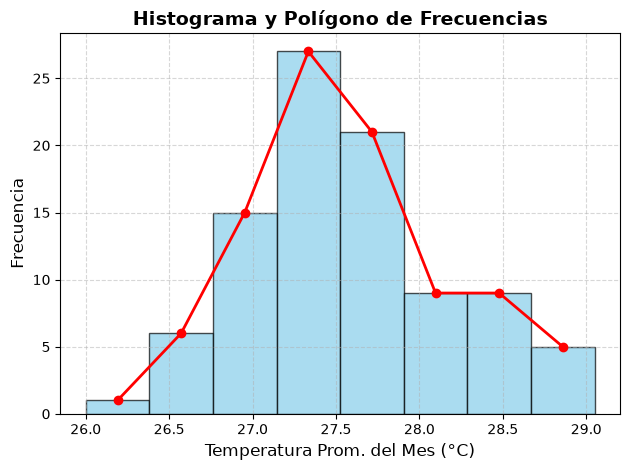

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Calcular frecuencias e intervalos
frecuencias, intervalos = np.histogram(variable, bins=8)

# Calcular puntos medios
puntos_medios = (intervalos[:-1] + intervalos[1:]) / 2


# Histograma
plt.hist(variable,bins=8, edgecolor="black", color="skyblue", alpha=0.7)

# Polígono de frecuencias
plt.plot(puntos_medios, frecuencias, color="red", marker="o", linewidth=2)
    
# Personalización del gráfico 
plt.title("Histograma y Polígono de Frecuencias", fontsize=14, fontweight="bold")
plt.xlabel(variable.name, fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [24]:
# Seleccionar la variable
variable = df["Acum. Lluvia Diaria"]

# Mostrar los primeros valores
variable.head()

0      0.00
1     18.50
2      6.35
3     60.50
4    228.95
Name: Acum. Lluvia Diaria, dtype: float64

In [25]:
media = variable.mean()
print("Media:", media)
mediana = variable.median()
print("Mediana:", mediana)
moda = variable.mode()
print("Moda:")
print(moda)

Media: 160.47311827956992
Mediana: 189.65
Moda:
0      10.4
1      15.0
2      26.9
3      69.7
4     103.7
5     174.1
6     220.8
7     235.4
8     247.5
9     250.4
10    331.0
Name: Acum. Lluvia Diaria, dtype: float64


In [26]:
rango = variable.max() - variable.min()
print("Rango:", rango)
varianza = variable.var()
print("Varianza:", varianza)
desviacion = variable.std()
print("Desviación estándar:", desviacion)
coef_variacion = (desviacion / media) * 100
print("Coeficiente de variación:", coef_variacion)
asimetria = (3 * (media - mediana)) / desviacion
print("Coeficiente de Asimetría de Pearson:", asimetria)

Rango: 449.0
Varianza: 12986.59883473586
Desviación estándar: 113.95875935940975
Coeficiente de variación: 71.01423626658473
Coeficiente de Asimetría de Pearson: -0.7680905412916179


In [27]:
from scipy.stats import kurtosis

curtosis = kurtosis(variable)
print("Curtosis:", curtosis)

Curtosis: -1.1058907523928825


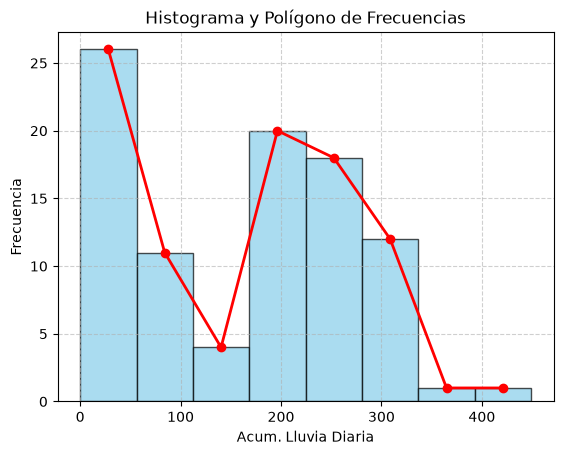

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Calcular frecuencias e intervalos
frecuencias, intervalos = np.histogram(variable, bins=8)

# Calcular puntos medios
puntos_medios = (intervalos[:-1] + intervalos[1:]) / 2


# Histograma
plt.hist(variable,bins=8, edgecolor="black", color="skyblue", alpha=0.7)

# Polígono de frecuencias
plt.plot(puntos_medios, frecuencias, color="red", marker="o", linewidth=2)
    
plt.title("Histograma y Polígono de Frecuencias") 
plt.xlabel("Acum. Lluvia Diaria")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()   

In [29]:
# Seleccionar la variable
variable = df["Precio Gasolina (95 Octanos)"]

# Mostrar los primeros valores
variable.head()

0    0.77
1    0.75
2    0.73
3    0.75
4    0.75
Name: Precio Gasolina (95 Octanos), dtype: float64

In [30]:
media = variable.mean()
print("Media:", media)
mediana = variable.median()
print("Mediana:", mediana)
moda = variable.mode()
print("Moda:")
print(moda)

Media: 0.9275268817204303
Mediana: 0.9
Moda:
0    0.87
1    0.90
Name: Precio Gasolina (95 Octanos), dtype: float64


In [31]:
rango = variable.max() - variable.min()
print("Rango:", rango)
varianza = variable.var()
print("Varianza:", varianza)
desviacion = variable.std()
print("Desviación estándar:", desviacion)
coef_variacion = (desviacion / media) * 100
print("Coeficiente de variación:", coef_variacion)
asimetria = (3 * (media - mediana)) / desviacion
print("Coeficiente de Asimetría de Pearson:", asimetria)

Rango: 0.81
Varianza: 0.02364925198690977
Desviación estándar: 0.1537831329727346
Coeficiente de variación: 16.579911159824153
Coeficiente de Asimetría de Pearson: 0.5369941655170478


In [32]:
from scipy.stats import kurtosis

curtosis = kurtosis(variable)
print("Curtosis:", curtosis)

Curtosis: 1.5586482295712702


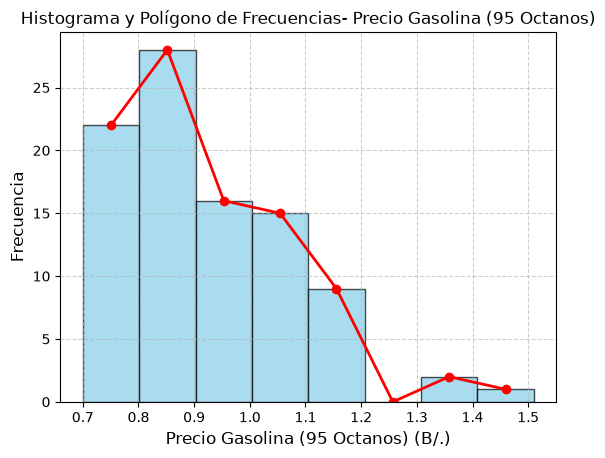

In [33]:
import numpy as np
import matplotlib.pyplot as plt

variable = df["Precio Gasolina (95 Octanos)"]

# Calcular frecuencias e intervalos
frecuencias, intervalos = np.histogram(variable, bins=8)

# Calcular puntos medios
puntos_medios = (intervalos[:-1] + intervalos[1:]) / 2

# Histograma
plt.hist(variable, bins=8, edgecolor="black", color="skyblue", alpha=0.7)

# Polígono de frecuencias
plt.plot(puntos_medios, frecuencias, color="red", marker="o", linewidth=2)

plt.title("Histograma y Polígono de Frecuencias- Precio Gasolina (95 Octanos)")
plt.xlabel("Precio Gasolina (95 Octanos) (B/.)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

In [34]:
# Seleccionar la variable
variable = df["IMAE"]

# Mostrar los primeros valores
variable.head()

0    309.60
1    312.23
2    315.04
3    317.64
4    319.50
Name: IMAE, dtype: float64

In [35]:
media = variable.mean()
print("Media:", media)
mediana = variable.median()
print("Mediana:", mediana)
moda = variable.mode()
print("Moda:")
print(moda)

Media: 287.5908602150538
Mediana: 271.99
Moda:
0     226.62
1     226.84
2     227.35
3     227.47
4     227.69
       ...  
88    344.32
89    344.79
90    345.63
91    345.81
92    346.66
Name: IMAE, Length: 93, dtype: float64


In [36]:
rango = variable.max() - variable.min()
print("Rango:", rango)
varianza = variable.var()
print("Varianza:", varianza)
desviacion = variable.std()
print("Desviación estándar:", desviacion)
coef_variacion = (desviacion / media) * 100
print("Coeficiente de variación:", coef_variacion)
asimetria = (3 * (media - mediana)) / desviacion
print("Coeficiente de Asimetría de Pearson:", asimetria)

Rango: 120.04000000000002
Varianza: 1645.0834166432915
Desviación estándar: 40.55962791549365
Coeficiente de variación: 14.103239541466687
Coeficiente de Asimetría de Pearson: 1.1539203649174237


In [37]:
from scipy.stats import kurtosis

curtosis = kurtosis(variable)
print("Curtosis:", curtosis)

Curtosis: -1.6281825708255038


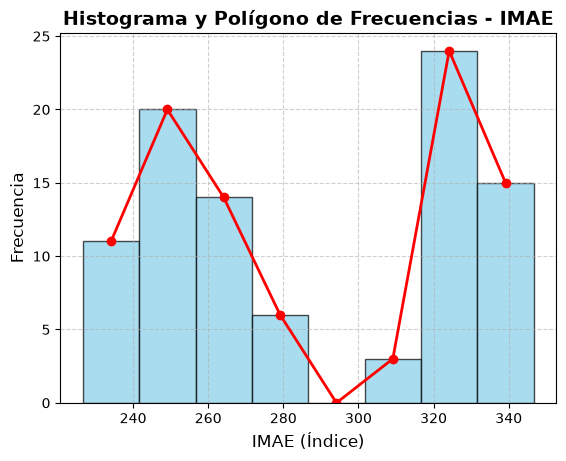

In [38]:
import numpy as np
import matplotlib.pyplot as plt

variable = df["IMAE"]

# Calcular frecuencias e intervalos
frecuencias, intervalos = np.histogram(variable, bins=8)

# Calcular puntos medios
puntos_medios = (intervalos[:-1] + intervalos[1:]) / 2

# Histograma
plt.hist(variable, bins=8, edgecolor="black", color="skyblue", alpha=0.7)

# Polígono de frecuencias
plt.plot(puntos_medios, frecuencias, color="red", marker="o", linewidth=2)

plt.title("Histograma y Polígono de Frecuencias - IMAE", fontsize=14, fontweight="bold")
plt.xlabel("IMAE (Índice)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()